# 01 — Exploratory Data Analysis
Understand the raw transaction data before feature engineering:
- Spend distribution by category
- Temporal patterns (hour / day-of-week)
- Customer-level spend distribution
- Merchant frequency ranking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

df = pd.read_csv('data/raw/fraudTrain.csv', index_col=0,
                 parse_dates=['trans_date_trans_time'])

# Clean merchant names (strip synthetic 'fraud_' prefix)
df['merchant'] = df['merchant'].str.replace('^fraud_', '', regex=True)

df['hour']        = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['is_weekend']  = df['trans_date_trans_time'].dt.dayofweek >= 5
df['month']       = df['trans_date_trans_time'].dt.to_period('M')

print(f'Loaded {len(df):,} transactions for {df["cc_num"].nunique()} customers')

Matplotlib is building the font cache; this may take a moment.


Loaded 1,296,675 transactions for 983 customers


## 1. Spend by Category

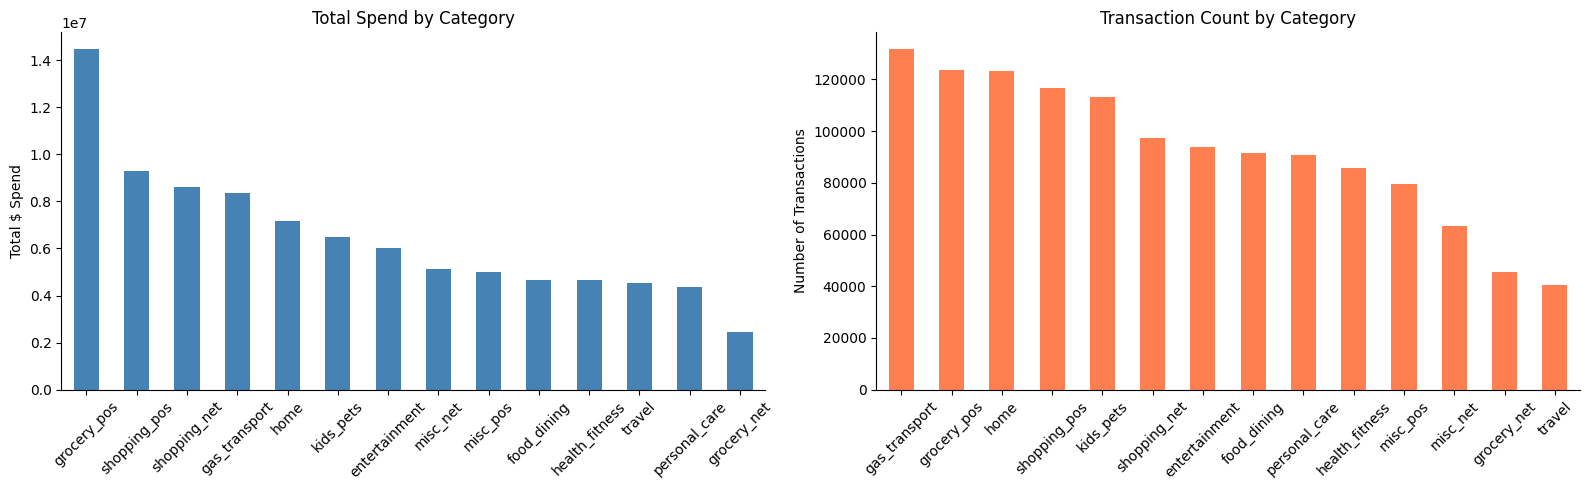

In [2]:
cat_spend = df.groupby('category')['amt'].sum().sort_values(ascending=False)
cat_txn   = df.groupby('category').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_spend.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Spend by Category')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total $ Spend')
axes[0].tick_params(axis='x', rotation=45)

cat_txn.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Transaction Count by Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/cluster_plots/eda_category_spend.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Temporal Patterns

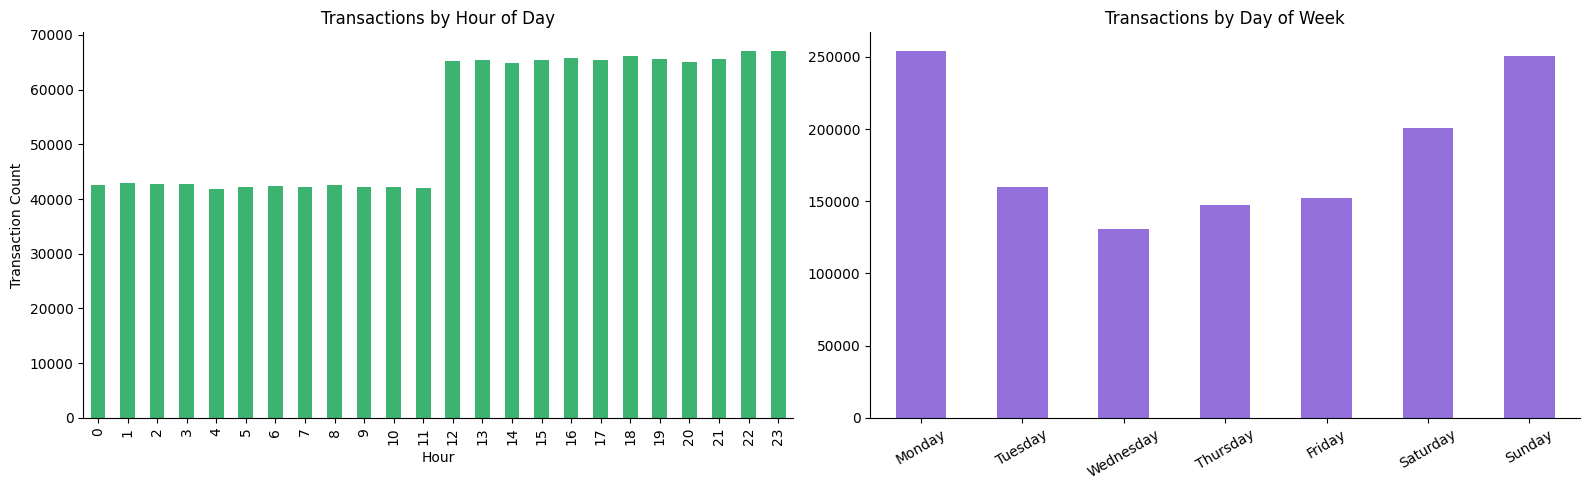

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hour of day
df.groupby('hour').size().plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Transactions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Transaction Count')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('day_of_week').size().reindex(day_order).plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/cluster_plots/eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Customer-Level Spend Distribution

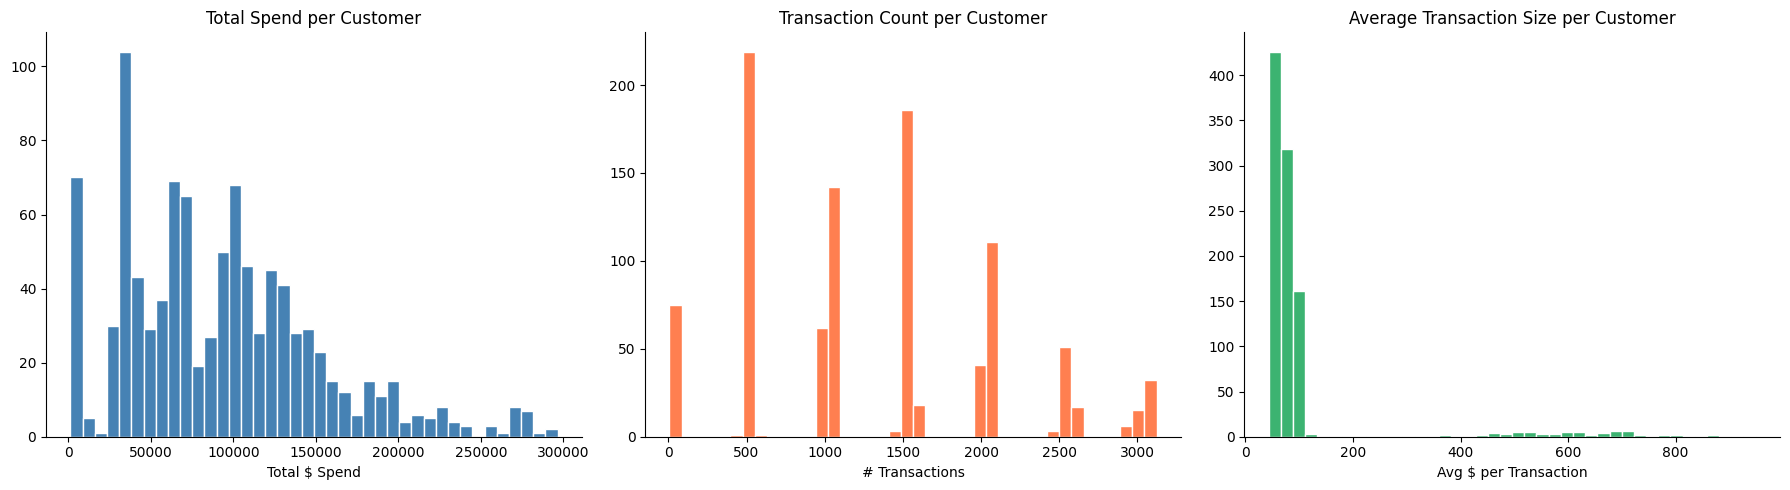

       total_spend    n_txn  avg_txn
count       983.00   983.00   983.00
mean      92800.03  1319.10   110.99
std       59584.78   812.24   146.60
min        1348.53     7.00    42.95
25%       43554.99   525.00    61.01
50%       88514.24  1054.00    67.56
75%      126784.21  2025.00    87.86
max      296436.73  3123.00   948.82


In [4]:
cust = df.groupby('cc_num').agg(
    total_spend=('amt', 'sum'),
    n_txn=('amt', 'count'),
    avg_txn=('amt', 'mean')
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(cust['total_spend'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Total Spend per Customer')
axes[0].set_xlabel('Total $ Spend')

axes[1].hist(cust['n_txn'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Transaction Count per Customer')
axes[1].set_xlabel('# Transactions')

axes[2].hist(cust['avg_txn'], bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average Transaction Size per Customer')
axes[2].set_xlabel('Avg $ per Transaction')

plt.tight_layout()
plt.savefig('outputs/cluster_plots/eda_customer_spend.png', dpi=150, bbox_inches='tight')
plt.show()

print(cust.describe().round(2))

## 4. Top Merchants by Transaction Volume

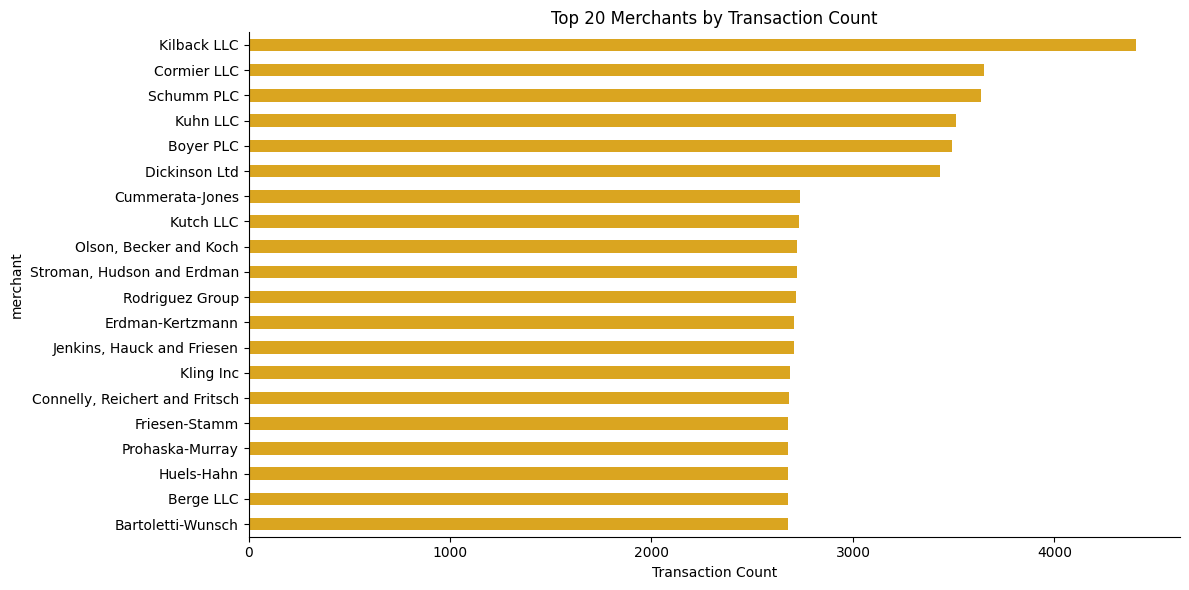

In [5]:
top_merchants = df.groupby('merchant').size().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_merchants.plot(kind='barh', color='goldenrod')
plt.title('Top 20 Merchants by Transaction Count')
plt.xlabel('Transaction Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/cluster_plots/eda_top_merchants.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Category Spend Heatmap — Sample of Customers

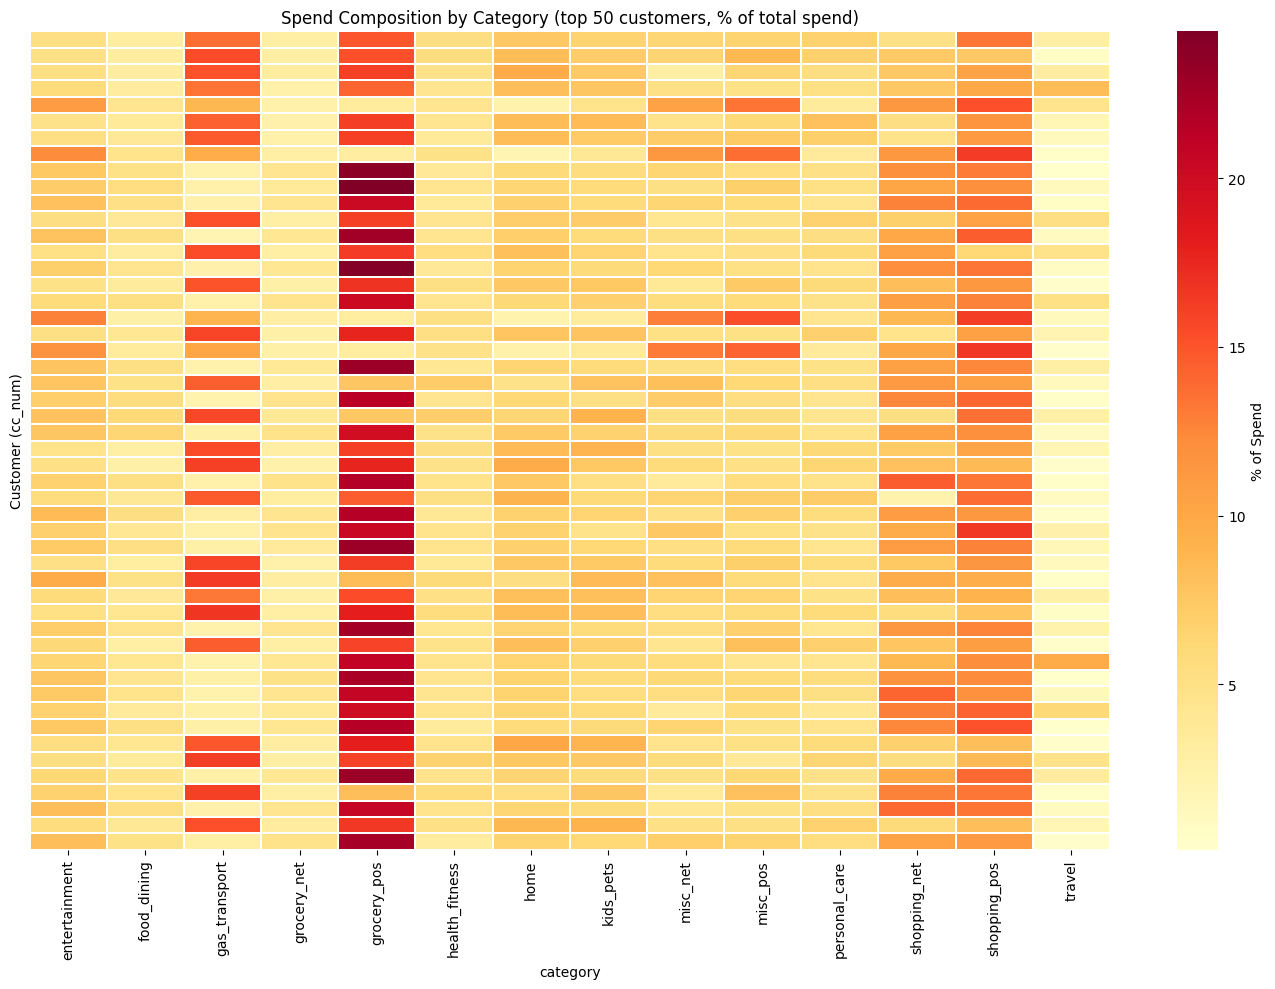

Visual diversity among customers is already visible — good signal for clustering.


In [6]:
# Pivot: customer x category spend (top 50 customers by transaction count)
top_custs = cust.nlargest(50, 'n_txn').index
pivot = df[df['cc_num'].isin(top_custs)].pivot_table(
    index='cc_num', columns='category', values='amt', aggfunc='sum', fill_value=0
)
# Normalize each customer to 100%
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_pct, cmap='YlOrRd', linewidths=0.3, annot=False,
            cbar_kws={'label': '% of Spend'})
plt.title('Spend Composition by Category (top 50 customers, % of total spend)')
plt.ylabel('Customer (cc_num)')
plt.yticks([])
plt.tight_layout()
plt.savefig('outputs/cluster_plots/eda_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visual diversity among customers is already visible — good signal for clustering.')